In [124]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.patches as patches

In [125]:
cohort = [
    #LS1
    "1_AlDe",
    "2_ReDo",
    "3_JuRo",
    "4_MaPo",
    "5_MaGo",
    "6_ElHa",
    #LS2
    "7_KlMe",
    "8_JuUe",
    "9_PhBa",
    "10_ToBa",
    "11_SePe",
    "12_ViDi",
    #LS3
    "13_FaPu",
    "14_JeBi",
    "15_DaEi",
    "16_MaEg",
    "17_JaDe",
    "18_InHo",
    #LS4
    "19_ToGr",
    "20_PeBu",
    "21_HaPr",
    "22_ClSt",
    "23_DaMe",
    ]

In [126]:
shovel = "Shovel"
cube = "Cube"

c_0 = "C0"
c_1 = "C1"
c_2 = "C2"
p_0 = "P0"
p_1 = "P1"
p_2 = "P2"

conditions = [c_0, c_1, c_2, p_0, p_1, p_2]

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

unity = "u"
imot = "i"

start_ts = "start"
end_ts = "end"

rhr = "resting_hr"

unity_unix_key = "ts_unix_ms"

unified_delta_key = "delta_ms"
unified_unix_key = "unix_ms"

imot_unix_key = "System Timestamp CAL"
imot_delta_ms_key = "Timestamp"
hr_key = 'Heart rate'
gsr_key = 'GSR Resistance CAL'
gsc_key = 'GSR Conductance CAL'

imot_keys = [imot_unix_key, imot_delta_ms_key, hr_key, gsr_key, gsc_key]

baseline_ms = 30_000

In [127]:
def get_df(p, e, c, s):
    path = './data/' + p + '/'  + s  + '_' + e + '_' + c + '.csv'
    return pd.read_csv(path)

def task_start(df):
    return df[unity_unix_key].min()

def task_end(df, e):
    if e == cube:
        final_target_reached = df[(df["cube_max_target_reached"] == 4)]

        return final_target_reached[unity_unix_key].min()
    else:
        final_load = df[(df["collision_or_load_count"] == 20)]
        final_unload = final_load[(final_load["shovel_loaded_state"] == False)]

        return final_unload[unity_unix_key].min()

def trim_imot(df, min_ts, max_ts):
    imot_start = df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    min_trimmed = df[(imot_start + df[imot_delta_ms_key] >= min_ts)]
    full_trimmed = min_trimmed[(imot_start + min_trimmed[imot_delta_ms_key] <= max_ts)]

    return full_trimmed

def sync_timestamps(unity_df, imot_df):
    task_start_ts = task_start(unity_df)

    unity_df[unified_unix_key] = unity_df[unity_unix_key]
    unity_df[unified_delta_key] = unity_df[unified_unix_key] - task_start_ts

    imot_start = imot_df.dropna(subset = imot_unix_key).iloc[0][imot_unix_key]

    imot_df[unified_unix_key] = imot_start + imot_df[imot_delta_ms_key]
    imot_df[unified_delta_key] = imot_df[unified_unix_key] - task_start_ts

    return [unity_df, imot_df]

def get_condition(p, e, c):
    imot_raw = get_df(p, e, c, imot).filter(items=imot_keys)
    unity_raw = get_df(p, e, c, unity)

    synced = sync_timestamps(unity_raw, imot_raw)
    unity_synced = synced[0]
    imot_synced = synced[1]

    task_start_ts = task_start(unity_raw)
    task_end_ts = task_end(unity_raw, e)

    baseline_imot = trim_imot(
        imot_raw,
        min_ts = 0,
        max_ts = task_start_ts
        )
    
    # task_imot = trim_imot(
    #     imot_raw,
    #     min_ts = task_start_ts - baseline_ms,
    #     max_ts = task_end_ts + baseline_ms
    #     )

    return {
        imot: imot_synced,
        unity: unity_synced,
        start_ts: task_start_ts,
        end_ts: task_end_ts,
        rhr: baseline_imot[hr_key].median()
    }

def get_experiment(p, e):
    return {
            c_0: get_condition(p, e, c_0),
            c_1: get_condition(p, e, c_1),
            c_2: get_condition(p, e, c_2),
            p_0: get_condition(p, e, p_0),
            p_1: get_condition(p, e, p_1),
            p_2: get_condition(p, e, p_2),
        }

def get_participant(p):
    return {
        cube: get_experiment(p, cube),
        shovel: get_experiment(p, shovel)
    }

In [128]:
data = list(map(lambda x: get_participant(x), cohort))

In [129]:
data[0][shovel][c_0][imot].head(3)

,System Timestamp CAL,Timestamp,Heart rate,GSR Resistance CAL,GSR Conductance CAL,unix_ms,delta_ms
0,NaN,3,NaN,NaN,NaN,1.750157e+12,-31446.580811
1,1.750157e+12,7,NaN,255.665855,3.911355,1.750157e+12,-31442.580811
2,1.750157e+12,14,NaN,255.761664,3.909890,1.750157e+12,-31435.580811


In [130]:
max_z_score = 3

def remove_outliers(df, key):
    cleaned = df.dropna(subset = key)
    smoothed = cleaned[np.abs(stats.zscore(cleaned[key])) < max_z_score]
    return smoothed

def single_median(df, key):
    return remove_outliers(df, key)[key].median()

def pre_mean_delta(p, key):
    start = p[start_ts]
    end = p[end_ts]

    pre = trim_imot(p[imot], min_ts = start - baseline_ms, max_ts = start)
    #post = trim_imot(p[imot], min_ts = end, max_ts = end + baseline_ms)
    total = trim_imot(p[imot], min_ts = start - baseline_ms, max_ts = end + baseline_ms)

    return (remove_outliers(total, key)[key].median() - remove_outliers(pre, key)[key].median())

def plot_experiments(cube_values, shovel_values, title, ylabel):
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))

    labels = conditions

    max_value = max(max(cube_values), max(shovel_values))
    min_value = min(min(cube_values), min(shovel_values))

    ylim = [min_value*0.9,max_value*1.1]

    axs[0].bar(labels, cube_values, color=colors)
    axs[0].set_title('[Cube] ' + title)
    axs[0].set_ylabel(ylabel)
    #axs[0].set_ylim(ylim)

    axs[1].bar(labels, shovel_values, color=colors)
    axs[1].set_title('[Shovel] ' + title)
    axs[1].set_ylabel(ylabel)
    #axs[0].set_ylim(ylim)

    plt.show()

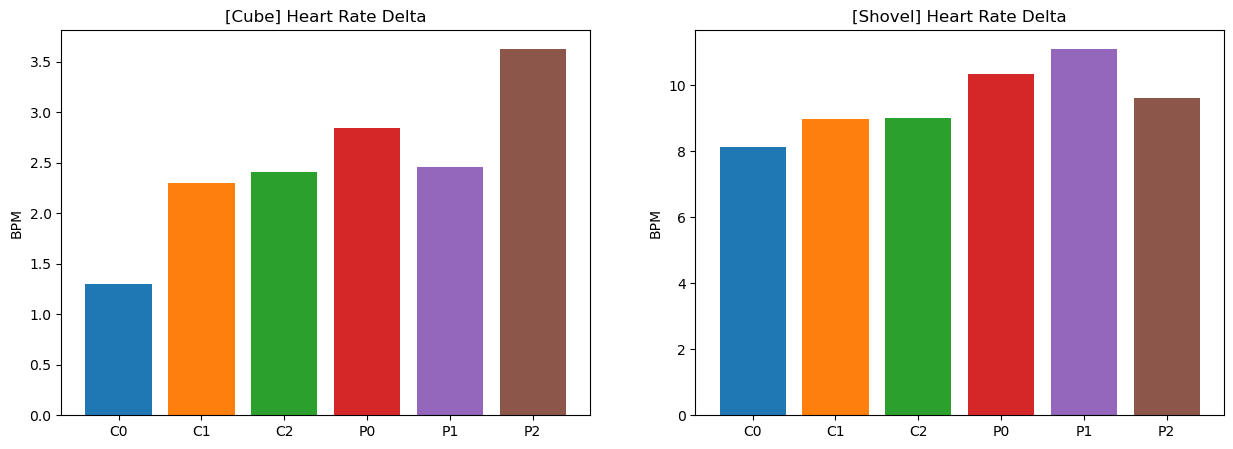

In [131]:
def agg_hr(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, hr_key), participants))
    return np.mean(single_values)

labels = conditions
cube_values = list(map(lambda x: agg_hr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_hr(data, shovel, x), conditions))



plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Heart Rate Delta',
    ylabel= 'BPM'
    )

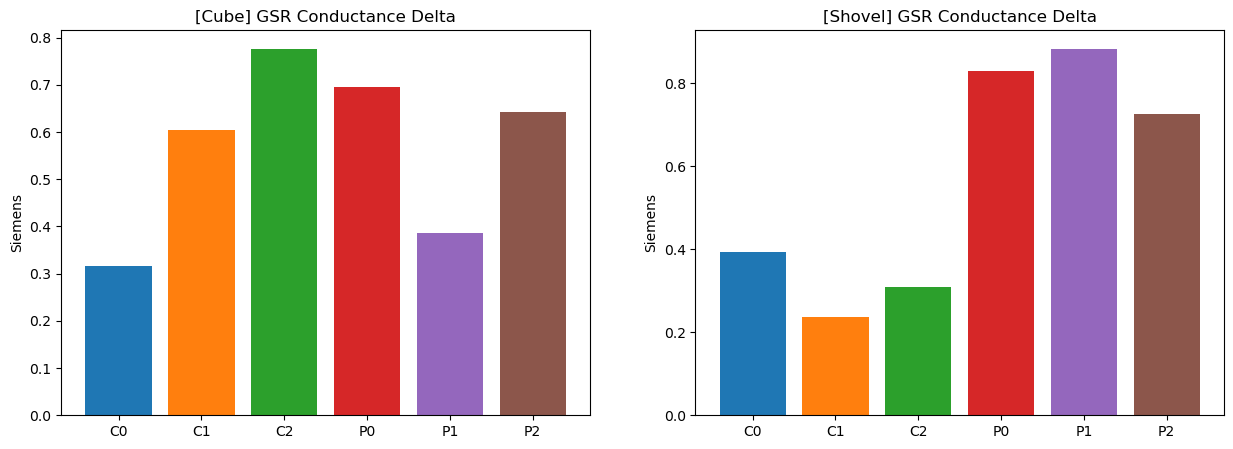

In [132]:
def agg_gsc(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, gsc_key), participants))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_gsc(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsc(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'GSR Conductance Delta',
    ylabel= 'Siemens'
    )

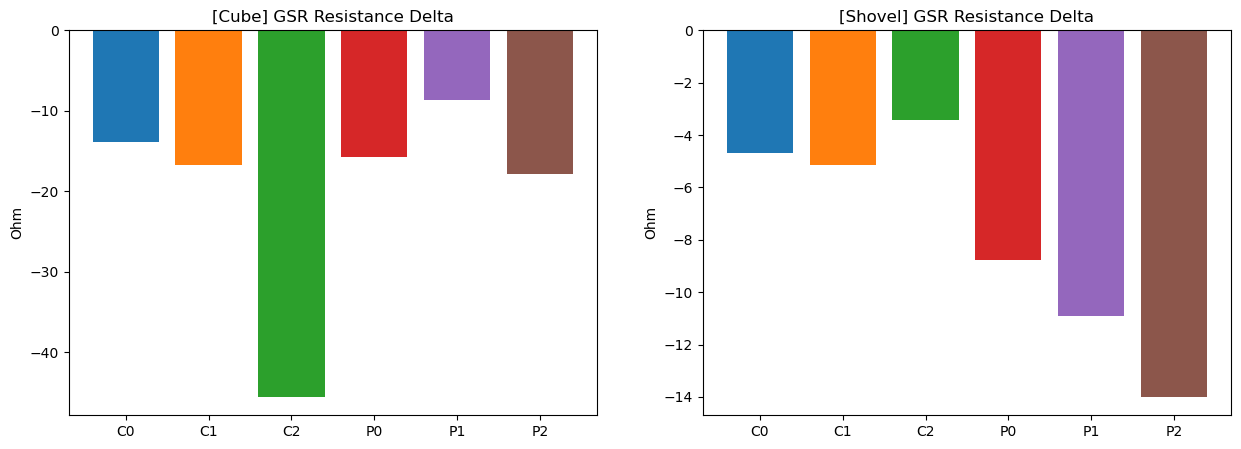

In [133]:
def agg_gsr(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(lambda x: pre_mean_delta(x, gsr_key), participants))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_gsr(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_gsr(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'GSR Resistance Delta',
    ylabel= 'Ohm'
    )

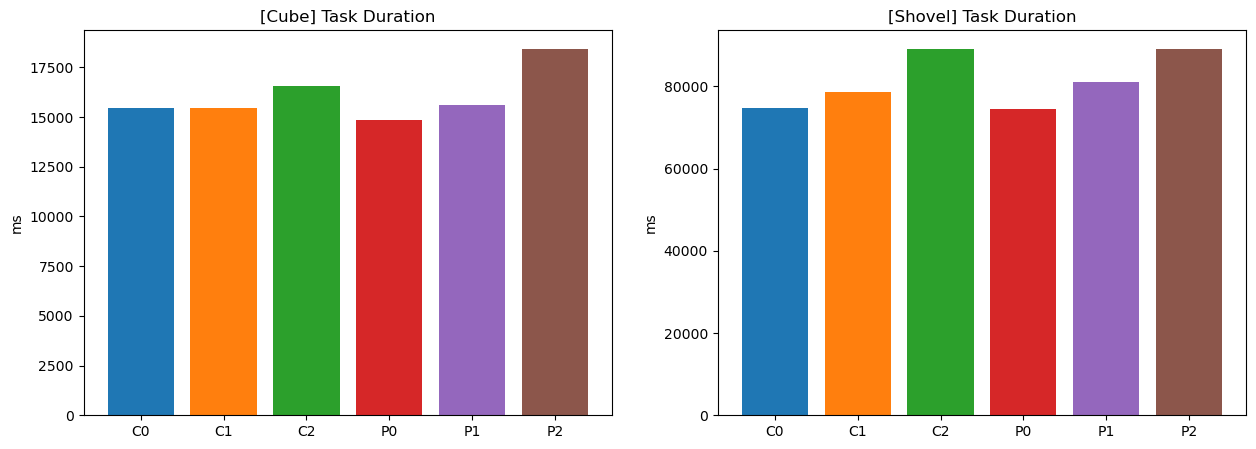

In [134]:
def single_duration(p):
    return p[end_ts] - p[start_ts]

def agg_duration(data, e, c):
    participants = list(map(lambda x: x[e][c], data))
    single_values = list(map(single_duration, participants))
    return np.mean(single_values)

cube_values = list(map(lambda x: agg_duration(data, cube, x), conditions))
shovel_values = list(map(lambda x: agg_duration(data, shovel, x), conditions))

plot_experiments(
    cube_values= cube_values,
    shovel_values= shovel_values,
    title= 'Task Duration',
    ylabel= 'ms'
    )

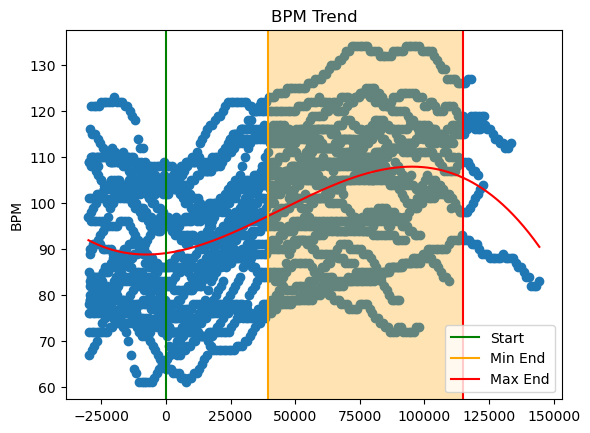

In [135]:
def plot_single_curve(df):
    cleaned = remove_outliers(df, hr_key)
    plt.scatter(cleaned[unified_delta_key], cleaned[hr_key])

    z = np.polyfit(cleaned[unified_delta_key], cleaned[hr_key], 3)
    p = np.poly1d(z)

    #add trendline to plot
    plt.plot(cleaned[unified_delta_key], p(cleaned[unified_delta_key]))

def agg_curve(data):
    fig, ax = plt.subplots()

    participants = list(map(lambda x: x[shovel][c_0], data))
    trimmmed_dfs = list(map(lambda x: trim_imot(x[imot], min_ts = x[start_ts] - baseline_ms, max_ts = x[end_ts] + baseline_ms), participants))
    smoothed_dfs = list(map(lambda x: remove_outliers(x, hr_key), trimmmed_dfs))

    all_values = pd.concat(smoothed_dfs).sort_values(by=unified_delta_key)

    x = all_values[unified_delta_key]
    y = all_values[hr_key]
    z = np.polyfit(x, y, 3)
    p = np.poly1d(z)

    plt.scatter(x, y)

    #add trendline to plot
    plt.plot(x, p(x), color="red")

    durations = list(map(lambda x: x[end_ts] - x[start_ts], participants))

    min_end = np.min(durations)
    max_end = np.max(durations)

    plt.axvline(x=0, color='green', label='Start')
    plt.axvline(x=min_end, color='orange', label='Min End')
    plt.axvline(x=max_end, color='red', label='Max End')

    ymin, ymax = ax.get_ylim()

    rect = patches.Rectangle((min_end, ymin), max_end-min_end, ymax-ymin, facecolor='orange')

    rect.set_alpha(0.3)

    # Add the patch to the Axes
    ax.add_patch(rect)

    #for df in trimmmed_dfs:
        #plot_single_curve(df)

agg_curve(data)
plt.legend()
plt.title('BPM Trend')
plt.ylabel('BPM')
#display plot
plt.show()